Rows and Columns: (50000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: flo

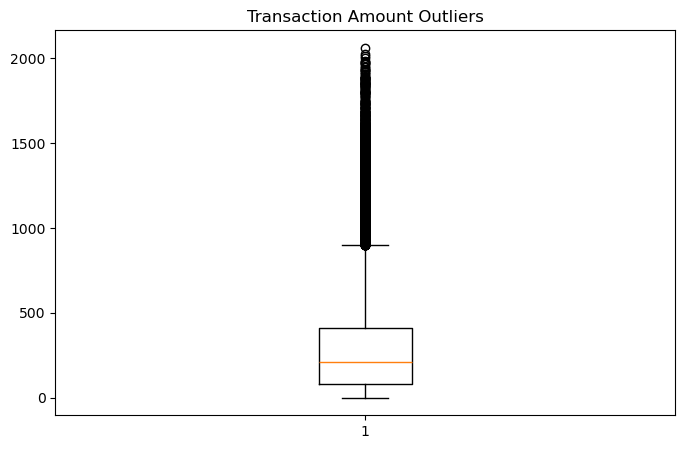

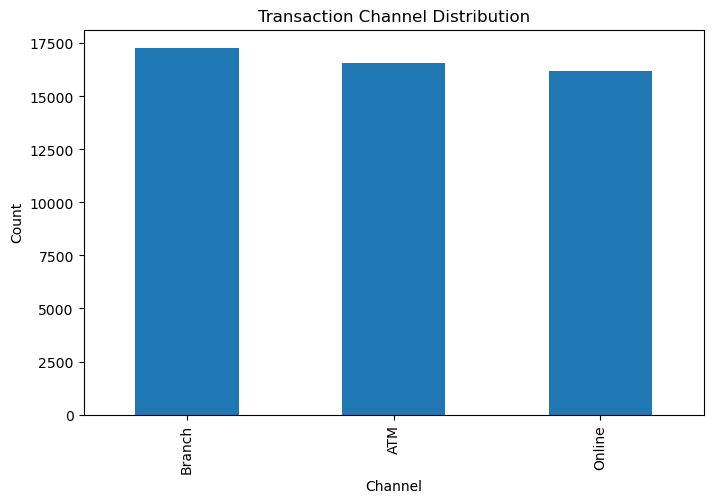

location
Fort Worth       1396
Charlotte        1347
Oklahoma City    1345
Philadelphia     1343
Memphis          1330
Tucson           1322
Los Angeles      1318
Omaha            1298
Miami            1278
Denver           1267
Name: count, dtype: int64
Cleaned Dataset Saved Successfully


(50000, 21)

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Load JSON Dataset

df = pd.read_json('csvjson (1).json')

# Display first 5 rows
df.head()

# Dataset Shape
print("Rows and Columns:", df.shape)

# Column Information
df.info()

# Statistical Summary
df.describe()

# Check Missing Values

missing_values = df.isnull().sum()

print(missing_values)
# Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

# Check Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)
# Remove Duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

# Convert TransactionDate to Datetime Format

df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='mixed',
    errors='coerce'
)

# Verify datatype
df['TransactionDate'].dtype

# Extract Year, Month, Day, Hour

df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['Day'] = df['TransactionDate'].dt.day
df['Hour'] = df['TransactionDate'].dt.hour

df.head()

# Convert Column Names to Lowercase

df.columns = df.columns.str.lower()

df.columns

# Convert Column Names to Lowercase

df.columns = df.columns.str.lower()

df.columns

# Transaction Type Count

df['transactiontype'].value_counts()

# Boxplot for Transaction Amount

plt.figure(figsize=(8,5))
plt.boxplot(df['transactionamount'])
plt.title('Transaction Amount Outliers')
plt.show()

# Create Suspicious Flag

df['suspicious_flag'] = np.where(
    (
        (df['transactionamount'] > 1000) |
        (df['loginattempts'] >= 3) |
        (df['accountbalance'] < df['transactionamount']) |
        (df['transactionduration'] < 20)
    ),
    1,
    0
)

df[['transactionid', 'suspicious_flag']].head()


# Risk Categorization

conditions = [
    (df['suspicious_flag'] == 1),
    (df['transactionamount'] > 500)
]

choices = ['High Risk', 'Medium Risk']

df['risk_level'] = np.select(conditions, choices, default='Low Risk')

df[['transactionid', 'risk_level']].head()

# Total Suspicious Transactions

df['suspicious_flag'].value_counts()
# View Suspicious Transactions

suspicious_txns = df[df['suspicious_flag'] == 1]

suspicious_txns.head()

# Devices Used By Multiple Accounts

device_risk = df.groupby('deviceid')['accountid'].nunique().reset_index()

device_risk.columns = ['deviceid', 'unique_accounts']

# High Risk Devices
high_risk_devices = device_risk[device_risk['unique_accounts'] > 1]

high_risk_devices.head()

# IPs Used By Multiple Accounts

ip_risk = df.groupby('ip address')['accountid'].nunique().reset_index()

ip_risk.columns = ['ip_address', 'unique_accounts']

# High Risk IPs
high_risk_ips = ip_risk[ip_risk['unique_accounts'] > 1]

high_risk_ips.head()

# Channel Distribution

df['channel'].value_counts()
# Channel Visualization

df['channel'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Transaction Channel Distribution')
plt.xlabel('Channel')
plt.ylabel('Count')

plt.show()

# Top Transaction Locations

location_analysis = df['location'].value_counts().head(10)

print(location_analysis)

# Save Cleaned Dataset

df.to_csv('cleaned_aml_transactions.csv', index=False)

print("Cleaned Dataset Saved Successfully")

# Final Dataset Preview

df.head()
# Final Dataset Shape

df.shape